In [9]:
import yfinance as yf

tcs = yf.download("TCS.NS", period="max")
tcs.to_csv("TCS.csv")

tcs.head()


C:\Users\Dell\AppData\Local\Temp\ipykernel_2316\1671149261.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs = yf.download("TCS.NS", period="max")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2002-08-12,26.297934,26.496658,25.652076,25.652076,212976
2002-08-13,25.941881,26.753343,25.751437,26.331052,153576
2002-08-14,24.153368,25.999853,23.664834,25.999853,822776
2002-08-15,24.153368,24.153368,24.153368,24.153368,0
2002-08-16,24.095402,25.171829,23.681391,24.029161,811856


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [18]:
import pandas as pd

# Load CSV with 2 header rows
df = pd.read_csv("TCS.csv", header=[0,1], index_col=0)

# Flatten multi-index columns (take the first row)
df.columns = [col[0] for col in df.columns]

df.head()



,Close,High,Low,Open,Volume
Date,,,,,
2002-08-12,26.297934,26.496658,25.652076,25.652076,212976
2002-08-13,25.941881,26.753343,25.751437,26.331052,153576
2002-08-14,24.153368,25.999853,23.664834,25.999853,822776
2002-08-15,24.153368,24.153368,24.153368,24.153368,0
2002-08-16,24.095402,25.171829,23.681391,24.029161,811856


In [12]:
# Keep only numeric columns (remove text like TCS.NS)
df = df.select_dtypes(include=['float64', 'int64'])

df.head()


""
0
1
2
3
4


In [19]:
# Detect the Close column automatically
possible_close_cols = [col for col in df.columns if "close" in col.lower()]
print("Detected close price column:", possible_close_cols)


Detected close price column: ['Close']


In [15]:
df.columns

Index([], dtype='object')

In [20]:
close_col = possible_close_cols[0]  # now it exists

df = df[[close_col]]
df.rename(columns={close_col: "Close"}, inplace=True)

df.head()


,Close
Date,
2002-08-12,26.297934
2002-08-13,25.941881
2002-08-14,24.153368
2002-08-15,24.153368
2002-08-16,24.095402


In [21]:
# Shift Close column by -1 to predict the next day's price
df["Prediction"] = df["Close"].shift(-1)

# Drop the last row which has NaN in Prediction
df = df[:-1]

df.head()


,Close,Prediction
Date,,
2002-08-12,26.297934,25.941881
2002-08-13,25.941881,24.153368
2002-08-14,24.153368,24.153368
2002-08-15,24.153368,24.095402
2002-08-16,24.095402,23.499231


In [22]:
# Features (X) and target (y)
X = df[["Close"]]      # input
y = df["Prediction"]   # output

# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
predictions = model.predict(X_test)
predictions[:10]  # show the first 10 predictions


array([2996.97372474,  832.97060605,  165.30450557, 3653.26312198,
         28.43003818,  100.03623086, 1171.06427003,   90.28334244,
        110.34467442,  439.01996378])

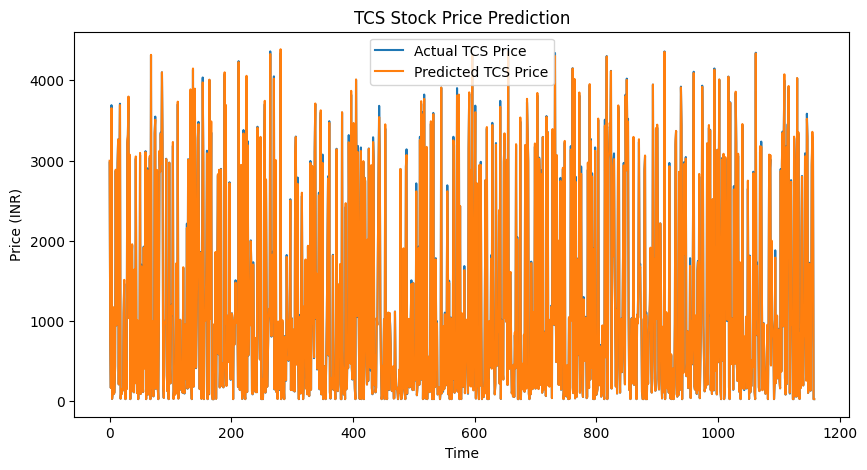

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual TCS Price")
plt.plot(predictions, label="Predicted TCS Price")
plt.title("TCS Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()
